In [93]:
import pandas as pd
df = pd.read_csv("hospital_data.csv")
df.shape

(15060, 20)

In [94]:
df.head()

,Admission_ID,Patient_ID,Patient_Name,Admission_Date,Discharge_Date,Department,Primary_Condition,Admission_Type,Patient_Age,Gender,City,Doctor,Insurance_Type,Payment_Method,Waiting_Time_Min,Length_of_Stay_Days,Room_Charges,Treatment_Charges,Medication_Charges,Total_Bill
0,A111558,P104538,Riya Singh,2025-11-11,2025-11-16,General Medicine,Infection,Emergency,52,Male,Mumbai,Dr. Rao,Corporate,Card,92.0,5,21796.53,21701.81,1565.92,45064.26
1,A108019,P101472,Arjun Iyer,2024-07-28,2024-07-30,Dermatology,Skin,Scheduled,27,Male,Thane,Dr. Shah,Government,Insurance,27.0,2,4581.68,2500.00,2813.26,9894.94
2,A108162,P101178,Neha Iyer,2025-04-07,2025-04-08,Dermatology,Skin,Scheduled,67,Female,Mumbai,Dr. Shah,Corporate,Card,23.0,1,3106.43,4739.04,3575.93,11421.40
3,A113834,P102561,Aarav Deshmukh,2025-01-25,2025-02-03,Neurology,Cardiac,Scheduled,37,Male,Mumbai,Dr. Iyer,Government,UPI,29.0,9,46217.11,28432.17,1922.25,76571.53
4,A108954,P102022,Amit Joshi,2024-11-05,2024-11-11,Pediatrics,Infection,Referral,14,Male,Mumbai,Dr. Nair,Private,Card,48.0,6,20744.78,19834.01,6106.37,46685.15


In [95]:
df.columns

Index(['Admission_ID', 'Patient_ID', 'Patient_Name', 'Admission_Date',
       'Discharge_Date', 'Department', 'Primary_Condition', 'Admission_Type',
       'Patient_Age', 'Gender', 'City', 'Doctor', 'Insurance_Type',
       'Payment_Method', 'Waiting_Time_Min', 'Length_of_Stay_Days',
       'Room_Charges', 'Treatment_Charges', 'Medication_Charges',
       'Total_Bill'],
      dtype='str')

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Admission_ID         15060 non-null  str    
 1   Patient_ID           15060 non-null  str    
 2   Patient_Name         14970 non-null  str    
 3   Admission_Date       15060 non-null  str    
 4   Discharge_Date       15060 non-null  str    
 5   Department           15060 non-null  str    
 6   Primary_Condition    15060 non-null  str    
 7   Admission_Type       15060 non-null  str    
 8   Patient_Age          15060 non-null  int64  
 9   Gender               15060 non-null  str    
 10  City                 14980 non-null  str    
 11  Doctor               14990 non-null  str    
 12  Insurance_Type       14995 non-null  str    
 13  Payment_Method       15004 non-null  str    
 14  Waiting_Time_Min     15000 non-null  float64
 15  Length_of_Stay_Days  15060 non-null  int64  
 1

In [97]:
df.isnull().sum()

Admission_ID            0
Patient_ID              0
Patient_Name           90
Admission_Date          0
Discharge_Date          0
Department              0
Primary_Condition       0
Admission_Type          0
Patient_Age             0
Gender                  0
City                   80
Doctor                 70
Insurance_Type         65
Payment_Method         56
Waiting_Time_Min       60
Length_of_Stay_Days     0
Room_Charges            0
Treatment_Charges      45
Medication_Charges      0
Total_Bill              0
dtype: int64

In [98]:
(df.isnull().sum()/len(df)*100).round(2)

Admission_ID           0.00
Patient_ID             0.00
Patient_Name           0.60
Admission_Date         0.00
Discharge_Date         0.00
Department             0.00
Primary_Condition      0.00
Admission_Type         0.00
Patient_Age            0.00
Gender                 0.00
City                   0.53
Doctor                 0.46
Insurance_Type         0.43
Payment_Method         0.37
Waiting_Time_Min       0.40
Length_of_Stay_Days    0.00
Room_Charges           0.00
Treatment_Charges      0.30
Medication_Charges     0.00
Total_Bill             0.00
dtype: float64

In [99]:
df["Admission_ID"].value_counts()

Admission_ID
A109744    2
A103025    2
A100898    2
A107389    2
A105818    2
          ..
A105192    1
A113419    1
A105391    1
A100861    1
A107271    1
Name: count, Length: 15000, dtype: int64

In [100]:
df["Patient_ID"].value_counts()

Patient_ID
P101647    10
P104061    10
P104397    10
P103607    10
P102381    10
           ..
P101752     1
P104426     1
P103436     1
P100854     1
P104618     1
Name: count, Length: 4751, dtype: int64

In [101]:
duplicate_admissions = df.loc[df["Admission_ID"].duplicated(keep=False), "Admission_ID"]

df[df["Admission_ID"].isin(duplicate_admissions)].sort_values("Admission_ID")
duplicate_admissions

55       A109744
317      A103025
368      A100898
631      A107389
926      A105818
          ...   
14590    A100001
14621    A112947
14647    A106605
14729    A101746
15035    A105312
Name: Admission_ID, Length: 120, dtype: str

In [102]:
df.loc[
    df["Admission_ID"].duplicated(keep=False)
].sort_values("Admission_ID")

,Admission_ID,Patient_ID,Patient_Name,Admission_Date,Discharge_Date,Department,Primary_Condition,Admission_Type,Patient_Age,Gender,City,Doctor,Insurance_Type,Payment_Method,Waiting_Time_Min,Length_of_Stay_Days,Room_Charges,Treatment_Charges,Medication_Charges,Total_Bill
14590,A100001,P102612,Priya Iyer,2024-12-03,2024-12-09,Orthopedics,Fracture/Injury,Scheduled,43,Male,Navi Mumbai,Dr. Patel,Private,UPI,53.0,6,30948.73,39586.95,16736.52,87272.20
3965,A100001,P102612,Priya Iyer,2024-12-03,2024-12-09,Orthopedics,Fracture/Injury,Scheduled,43,Male,Navi Mumbai,Dr. Patel,Private,UPI,53.0,6,30948.73,39586.95,16736.52,87272.20
6187,A100176,P104877,Kavya Verma,2024-04-09,2024-04-18,Neurology,Neurological,Emergency,38,Male,Thane,Dr. Iyer,Government,Cash,80.0,9,45494.29,38236.01,3095.74,86826.04
6808,A100176,P104877,Kavya Verma,2024-04-09,2024-04-18,Neurology,Neurological,Emergency,38,Male,Thane,Dr. Iyer,Government,Cash,80.0,9,45494.29,38236.01,3095.74,86826.04
11626,A100476,P104832,Ananya Iyer,2024-10-11,2024-10-15,General Medicine,Gastrointestinal,Scheduled,34,Female,Nagpur,Dr. Sharma,Private,Card,49.0,4,16003.27,20246.46,6083.47,42333.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7085,A114846,P104646,Meera Deshmukh,2024-11-14,2024-11-18,ENT,Respiratory,Referral,61,MALE,Nagpur,Dr. Gupta,Government,UPI,28.0,4,12245.23,8984.53,4923.94,26153.69
1211,A114855,P101547,Riya Patil,2025-09-12,2025-09-19,Cardiology,General,Emergency,40,Male,Mumbai,Dr. Khan,Government,Card,72.0,7,40283.52,31381.22,2362.64,74027.38
4576,A114855,P101547,Riya Patil,2025-09-12,2025-09-19,Cardiology,General,Emergency,40,Male,Mumbai,Dr. Khan,Government,Card,72.0,7,40283.52,31381.22,2362.64,74027.38
10757,A114936,P101647,Priya Deshmukh,2025-06-26,2025-06-30,Gynecology,General,Scheduled,14,Female,Mumbai,Dr. Kulkarni,Private,UPI,47.0,4,14861.11,10484.88,4201.80,29547.80


In [103]:
df.duplicated().sum()

np.int64(60)

In [104]:
df_clean = df.drop_duplicates().copy()

In [105]:
df_clean.shape

(15000, 20)

In [106]:
df_clean["Admission_ID"].duplicated().sum()

np.int64(0)

In [107]:
df_clean["Patient_ID"].value_counts().describe()

count    4751.000000
mean        3.157230
std         1.635498
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: count, dtype: float64

In [108]:
df_clean.dtypes

Admission_ID               str
Patient_ID                 str
Patient_Name               str
Admission_Date             str
Discharge_Date             str
Department                 str
Primary_Condition          str
Admission_Type             str
Patient_Age              int64
Gender                     str
City                       str
Doctor                     str
Insurance_Type             str
Payment_Method             str
Waiting_Time_Min       float64
Length_of_Stay_Days      int64
Room_Charges           float64
Treatment_Charges      float64
Medication_Charges     float64
Total_Bill             float64
dtype: object

In [109]:
df_clean[["Admission_Date", "Discharge_Date"]].head()

,Admission_Date,Discharge_Date
0,2025-11-11,2025-11-16
1,2024-07-28,2024-07-30
2,2025-04-07,2025-04-08
3,2025-01-25,2025-02-03
4,2024-11-05,2024-11-11


In [110]:
df_clean["Admission_Date_Raw"] = df_clean["Admission_Date"]
df_clean["Discharge_Date_Raw"] = df_clean["Discharge_Date"]

df_clean["Admission_Date"] = pd.to_datetime(
    df_clean["Admission_Date"], errors="coerce"
)

df_clean["Discharge_Date"] = pd.to_datetime(
    df_clean["Discharge_Date"], errors="coerce"
)

df_clean[["Admission_Date", "Discharge_Date"]].isna().sum()

Admission_Date    80
Discharge_Date    80
dtype: int64

In [111]:
invalid_dates = df_clean[
    df_clean["Admission_Date"] > df_clean["Discharge_Date"]
]

invalid_dates.shape

(20, 22)

In [ ]:
# Show the records where discharge happened before admission.
# We need to understand whether these are data-entry/date-format problems

invalid_dates[
    [
        "Admission_ID",
        "Patient_ID",
        "Admission_Date",
        "Discharge_Date",
        "Length_of_Stay_Days"
    ]
].sort_values("Admission_Date")

,Admission_ID,Patient_ID,Admission_Date,Discharge_Date,Length_of_Stay_Days
7937,A101322,P104138,2024-02-29,2024-02-28,8
8498,A102940,P101985,2024-04-30,2024-04-29,2
6963,A104552,P100761,2024-05-02,2024-04-29,5
10098,A103646,P100085,2024-08-03,2024-08-01,4
2070,A108652,P101133,2024-08-12,2024-08-10,6
10409,A104409,P104651,2024-08-21,2024-08-19,4
2931,A111091,P101020,2024-08-25,2024-08-22,3
3279,A114550,P101624,2024-11-19,2024-11-16,4
11438,A102724,P101451,2024-11-20,2024-11-19,2
6553,A106099,P101567,2025-01-14,2025-01-13,4


In [ ]:
# The converted dates show a business-rule violation.
#the original raw values to see whether the problem came from date formatting/conversion.
invalid_dates[
    [
        "Admission_ID",
        "Patient_ID",
        "Admission_Date_Raw",
        "Discharge_Date_Raw",
        "Admission_Date",
        "Discharge_Date",
        "Length_of_Stay_Days"
    ]
].sort_values("Admission_ID")

,Admission_ID,Patient_ID,Admission_Date_Raw,Discharge_Date_Raw,Admission_Date,Discharge_Date,Length_of_Stay_Days
2902,A100115,P103699,2025-10-25,2025-10-24,2025-10-25,2025-10-24,2
7937,A101322,P104138,2024-02-29,2024-02-28,2024-02-29,2024-02-28,8
6614,A102009,P104641,2025-08-12,2025-08-11,2025-08-12,2025-08-11,7
1308,A102013,P102858,2025-11-02,2025-10-30,2025-11-02,2025-10-30,2
156,A102035,P103519,2025-05-11,2025-05-09,2025-05-11,2025-05-09,4
11438,A102724,P101451,2024-11-20,2024-11-19,2024-11-20,2024-11-19,2
8498,A102940,P101985,2024-04-30,2024-04-29,2024-04-30,2024-04-29,2
5705,A103499,P102748,2025-01-18,2025-01-17,2025-01-18,2025-01-17,4
4713,A103575,P100076,2025-12-01,2025-11-28,2025-12-01,2025-11-28,3
10098,A103646,P100085,2024-08-03,2024-08-01,2024-08-03,2024-08-01,4


In [ ]:
# Flag records where the discharge date occurs before the admission date.

df_clean["Invalid_Date_Flag"] = (
    df_clean["Admission_Date"] > df_clean["Discharge_Date"]
)

# Check how many records are affected.
df_clean["Invalid_Date_Flag"].value_counts()

Invalid_Date_Flag
False    14980
True        20
Name: count, dtype: int64

In [ ]:
# Check how many records have a missing Admission_Date or Discharge_Date.

missing_dates = df_clean[
    df_clean["Admission_Date"].isna() |
    df_clean["Discharge_Date"].isna()
]

missing_dates.shape

(160, 23)

In [ ]:
# View the affected records and their original raw date values.

missing_dates[
    [
        "Admission_ID",
        "Patient_ID",
        "Admission_Date_Raw",
        "Discharge_Date_Raw",
        "Admission_Date",
        "Discharge_Date"
    ]
].head(20)

,Admission_ID,Patient_ID,Admission_Date_Raw,Discharge_Date_Raw,Admission_Date,Discharge_Date
114,A100863,P100398,2025-05-29,02/06/2025,2025-05-29,NaT
402,A114570,P102514,07/06/2025,2025-07-08,NaT,2025-07-08
444,A105407,P101958,22/01/2024,2024-01-29,NaT,2024-01-29
620,A102120,P104367,2024-06-14,21/06/2024,2024-06-14,NaT
690,A113907,P101469,12/27/2025,2026-01-01,NaT,2026-01-01
746,A114807,P102607,2024-07-16,07/19/2024,2024-07-16,NaT
752,A100928,P101697,2024-01-25,29/01/2024,2024-01-25,NaT
832,A110939,P104551,2025-06-13,06/18/2025,2025-06-13,NaT
1068,A111110,P102128,2025-02-12,17-Feb-2025,2025-02-12,NaT
1110,A107697,P103592,25/10/2024,2024-11-02,NaT,2024-11-02


In [ ]:
# Check whether the original date values are actually present

missing_dates[
    ["Admission_Date_Raw", "Discharge_Date_Raw"]
].isna().sum()

Admission_Date_Raw    0
Discharge_Date_Raw    0
dtype: int64

In [118]:
# Check whether the records with missing Admission_Date
# have a valid Discharge_Date and Length_of_Stay_Days.
missing_admission = df_clean[
    df_clean["Admission_Date"].isna()
]

missing_admission[
    [
        "Discharge_Date",
        "Length_of_Stay_Days"
    ]
].isna().sum()

Discharge_Date         0
Length_of_Stay_Days    0
dtype: int64

In [119]:
# Check whether the records with missing Discharge_Date
# have a valid Admission_Date and Length_of_Stay_Days.
missing_discharge = df_clean[
    df_clean["Discharge_Date"].isna()
]

missing_discharge[
    [
        "Admission_Date",
        "Length_of_Stay_Days"
    ]
].isna().sum()

Admission_Date         0
Length_of_Stay_Days    0
dtype: int64

In [ ]:
# Reconstruct missing admission dates using the known
# discharge date and recorded length of stay.

df_clean.loc[
    df_clean["Admission_Date"].isna(),
    "Admission_Date"
] = (
    df_clean.loc[
        df_clean["Admission_Date"].isna(),
        "Discharge_Date"
    ]
    - pd.to_timedelta(
        df_clean.loc[
            df_clean["Admission_Date"].isna(),
            "Length_of_Stay_Days"
        ],
        unit="D"
    )
)

In [121]:
# Reconstruct missing discharge dates using the known
# admission date and recorded length of stay.
df_clean.loc[
    df_clean["Discharge_Date"].isna(),
    "Discharge_Date"
] = (
    df_clean.loc[
        df_clean["Discharge_Date"].isna(),
        "Admission_Date"
    ]
    + pd.to_timedelta(
        df_clean.loc[
            df_clean["Discharge_Date"].isna(),
            "Length_of_Stay_Days"
        ],
        unit="D"
    )
)

In [122]:
# Confirm that all previously missing admission/discharge dates
# have now been reconstructed.
df_clean[["Admission_Date", "Discharge_Date"]].isna().sum()

Admission_Date    0
Discharge_Date    0
dtype: int64

In [ ]:
# Recalculate Length of Stay independently from the cleaned dates.

df_clean["Length_of_Stay_Calc"] = (
    df_clean["Discharge_Date"] - df_clean["Admission_Date"]
).dt.days



# Identify records where the recorded Length of Stay
# does not agree with the dates.
los_mismatch = df_clean[
    df_clean["Length_of_Stay_Days"] != df_clean["Length_of_Stay_Calc"]
]

# Count the mismatched records.
los_mismatch.shape

(26, 24)

In [124]:
# Check whether any admission still occurs after discharge.
# This should identify the 20 previously flagged records.
(df_clean["Admission_Date"] > df_clean["Discharge_Date"]).sum()

np.int64(20)

In [125]:
# Review all records where recorded LOS does not match
# the LOS calculated from admission and discharge dates.
los_mismatch[
    [
        "Admission_ID",
        "Admission_Date",
        "Discharge_Date",
        "Length_of_Stay_Days",
        "Length_of_Stay_Calc"
    ]
].sort_values("Admission_ID")

,Admission_ID,Admission_Date,Discharge_Date,Length_of_Stay_Days,Length_of_Stay_Calc
2902,A100115,2025-10-25,2025-10-24,2,-1
7937,A101322,2024-02-29,2024-02-28,8,-1
6614,A102009,2025-08-12,2025-08-11,7,-1
1308,A102013,2025-11-02,2025-10-30,2,-3
156,A102035,2025-05-11,2025-05-09,4,-2
11438,A102724,2024-11-20,2024-11-19,2,-1
8498,A102940,2024-04-30,2024-04-29,2,-1
12393,A103226,2025-08-12,2025-08-21,60,9
5705,A103499,2025-01-18,2025-01-17,4,-1
4713,A103575,2025-12-01,2025-11-28,3,-3


In [ ]:
# Correct LOS only where admission and discharge dates are valid.


valid_los_mismatch = los_mismatch[
    df_clean["Admission_Date"] <= df_clean["Discharge_Date"]
]

df_clean.loc[
    valid_los_mismatch.index,
    "Length_of_Stay_Days"
] = df_clean.loc[
    valid_los_mismatch.index,
    "Length_of_Stay_Calc"
]

C:\Users\DELL\AppData\Local\Temp\ipykernel_6548\792291995.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  valid_los_mismatch = los_mismatch[


In [ ]:
# Flag records where admission occurs after discharge.


df_clean["Invalid_Date_Flag"] = (
    df_clean["Admission_Date"] > df_clean["Discharge_Date"]
)


In [128]:
# Confirm the number of logically invalid date records.

df_clean["Invalid_Date_Flag"].value_counts()

Invalid_Date_Flag
False    14980
True        20
Name: count, dtype: int64

In [129]:
# Final validation: for all records with logically valid dates,
# recorded Length of Stay should now match the date-based calculation.

valid_records = df_clean[
    df_clean["Invalid_Date_Flag"] == False
]

(
    valid_records["Length_of_Stay_Days"]
    == valid_records["Length_of_Stay_Calc"]
).sum()

np.int64(14980)

In [130]:
# Confirm that the date columns are stored as datetime
# and Length of Stay is numeric.

df_clean[
    ["Admission_Date", "Discharge_Date", "Length_of_Stay_Days"]
].dtypes

Admission_Date         datetime64[us]
Discharge_Date         datetime64[us]
Length_of_Stay_Days             int64
dtype: object

In [ ]:
# Select the main numeric columns in the hospital dataset.


numeric_cols = [
    "Patient_Age",
    "Waiting_Time_Min",
    "Length_of_Stay_Days",
    "Room_Charges",
    "Treatment_Charges",
    "Medication_Charges",
    "Total_Bill"
]

df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_Age,15000.0,41.227267,21.498202,-3.0,26.0000,41.000,57.0000,150.000000
Waiting_Time_Min,14940.0,56.407564,23.962294,-10.0,41.0000,56.000,72.0000,999.000000
Length_of_Stay_Days,15000.0,5.377800,2.141286,1.0,4.0000,5.000,7.0000,16.000000
Room_Charges,15000.0,23606.886088,13102.834817,1500.0,13164.5075,20582.035,33124.9850,89838.740000
Treatment_Charges,14955.0,20429.330672,11523.794244,2500.0,11257.6150,17732.960,30067.6200,123739.994271
Medication_Charges,15000.0,5392.311884,3117.450289,500.0,3090.6600,4834.390,7031.9125,25000.000000
Total_Bill,15000.0,49427.514863,23488.105163,5457.4,30665.1400,43298.105,69072.1975,173333.010000


In [ ]:
# Check records with an unrealistic patient age.


invalid_age = df_clean[
    (df_clean["Patient_Age"] < 0) |
    (df_clean["Patient_Age"] > 100)
]

# Count the affected records.
invalid_age.shape

(5, 24)

In [133]:
# Inspect the actual invalid age values before deciding
# whether they should be corrected, treated as missing, or flagged.

invalid_age[
    [
        "Admission_ID",
        "Patient_ID",
        "Patient_Age",
        "Department",
        "Primary_Condition"
    ]
]

,Admission_ID,Patient_ID,Patient_Age,Department,Primary_Condition
1797,A108261,P100156,130,Gynecology,Infection
3316,A112722,P104235,-1,General Medicine,Infection
5509,A106019,P104696,-3,ENT,Respiratory
10874,A106319,P101582,125,Orthopedics,General
14514,A113366,P103342,150,ENT,Respiratory


In [ ]:
# Replace impossible patient ages with NaN.

import numpy as np
df_clean.loc[
    (df_clean["Patient_Age"] < 0) |
    (df_clean["Patient_Age"] > 100),
    "Patient_Age"
] = np.nan

# Confirm that the five invalid ages have been converted to missing values.

df_clean["Patient_Age"].isna().sum()

np.int64(5)

In [ ]:
# Identify clearly invalid or suspicious waiting-time values.
# Negative waiting time is impossible, while 999 may be a placeholder


invalid_waiting = df_clean[
    (df_clean["Waiting_Time_Min"] < 0) |
    (df_clean["Waiting_Time_Min"] >= 999)
]

# Count the affected records.
invalid_waiting.shape

(3, 24)

In [ ]:
# Inspect the actual suspicious waiting-time records.

invalid_waiting[
    [
        "Admission_ID",
        "Department",
        "Admission_Type",
        "Waiting_Time_Min"
    ]
].sort_values("Waiting_Time_Min")

,Admission_ID,Department,Admission_Type,Waiting_Time_Min
1418,A101490,General Medicine,Scheduled,-10.0
4326,A104185,Dermatology,Emergency,-5.0
9596,A111115,Orthopedics,Walk-in,999.0


In [137]:
# Identify impossible/suspicious waiting-time values.
# Waiting time cannot be negative, and 999 appears to be a placeholder/error value.

invalid_waiting = df_clean[
    (df_clean["Waiting_Time_Min"] < 0) |
    (df_clean["Waiting_Time_Min"] == 999)
]

# Check how many records are affected
invalid_waiting.shape

(3, 24)

In [ ]:
# Replace invalid waiting-time values with NaN.


df_clean.loc[
    (df_clean["Waiting_Time_Min"] < 0) |
    (df_clean["Waiting_Time_Min"] == 999),
    "Waiting_Time_Min"
] = np.nan



# Median is preferred because it is less affected by outliers than the mean.

waiting_median = df_clean["Waiting_Time_Min"].median()

df_clean["Waiting_Time_Min"] = df_clean["Waiting_Time_Min"].fillna(
    waiting_median
)


# Confirm that no missing values remain in Waiting_Time_Min.

df_clean["Waiting_Time_Min"].isna().sum()

np.int64(0)

In [139]:
# Inspect records with unrealistic patient ages
invalid_age = df_clean[
    (df_clean["Patient_Age"] < 0) |
    (df_clean["Patient_Age"] > 100)
]

invalid_age[
    [
        "Admission_ID",
        "Patient_ID",
        "Patient_Age",
        "Department",
        "Primary_Condition"
    ]
]

,Admission_ID,Patient_ID,Patient_Age,Department,Primary_Condition


In [140]:
# Confirm that no missing values remain in Patient_Age
df_clean["Patient_Age"].isna().sum()

np.int64(5)

In [141]:
# Inspect records where Patient_Age is missing
missing_age = df_clean[df_clean["Patient_Age"].isna()]

missing_age[
    [
        "Admission_ID",
        "Patient_ID",
        "Patient_Age",
        "Department",
        "Primary_Condition"
    ]
]

,Admission_ID,Patient_ID,Patient_Age,Department,Primary_Condition
1797,A108261,P100156,NaN,Gynecology,Infection
3316,A112722,P104235,NaN,General Medicine,Infection
5509,A106019,P104696,NaN,ENT,Respiratory
10874,A106319,P101582,NaN,Orthopedics,General
14514,A113366,P103342,NaN,ENT,Respiratory


In [142]:
# Calculate the median age from the valid patient ages
median_age = df_clean["Patient_Age"].median()

# Fill the 5 missing ages with the median
df_clean["Patient_Age"] = df_clean["Patient_Age"].fillna(median_age)

# Confirm that no missing ages remain
df_clean["Patient_Age"].isna().sum()

np.int64(0)

In [143]:
# Inspect records where Treatment_Charges is missing
missing_treatment = df_clean[
    df_clean["Treatment_Charges"].isna()
]

missing_treatment[
    [
        "Admission_ID",
        "Patient_ID",
        "Department",
        "Primary_Condition",
        "Room_Charges",
        "Medication_Charges",
        "Treatment_Charges",
        "Total_Bill"
    ]
]

,Admission_ID,Patient_ID,Department,Primary_Condition,Room_Charges,Medication_Charges,Treatment_Charges,Total_Bill
71,A102627,P101950,General Medicine,General,19822.12,7507.03,NaN,36316.22
882,A102639,P104730,Cardiology,Respiratory,78904.87,6020.02,NaN,117261.53
963,A113251,P100327,General Medicine,Infection,21910.70,5935.32,NaN,47370.11
1445,A113872,P101905,Neurology,General,34984.41,5686.25,NaN,73010.86
1705,A109097,P102276,Neurology,General,31574.30,5787.75,NaN,59551.72
2697,A108210,P103429,Cardiology,Respiratory,45264.81,5129.35,NaN,82187.37
3214,A110890,P100521,Dermatology,General,1662.19,6133.52,NaN,10295.72
3955,A114045,P101423,Neurology,General,31402.94,5032.06,NaN,61308.35
4237,A103101,P100252,Orthopaedics,General,29762.58,4626.16,NaN,62231.88
5437,A114415,P104832,Pediatrics,Infection,16645.53,7220.66,NaN,37425.29


In [144]:
# Calculate the median treatment charge from existing valid values
median_treatment = df_clean["Treatment_Charges"].median()

# Fill the 45 missing treatment charges with the median
df_clean["Treatment_Charges"] = df_clean["Treatment_Charges"].fillna(median_treatment)

# Confirm that no missing treatment charges remain
df_clean["Treatment_Charges"].isna().sum()

np.int64(0)

In [145]:
# Check for negative values in important numeric columns
numeric_cols = [
    "Patient_Age",
    "Waiting_Time_Min",
    "Length_of_Stay_Days",
    "Room_Charges",
    "Treatment_Charges",
    "Medication_Charges",
    "Total_Bill"
]

(df_clean[numeric_cols] < 0).sum()

Patient_Age            0
Waiting_Time_Min       0
Length_of_Stay_Days    0
Room_Charges           0
Treatment_Charges      0
Medication_Charges     0
Total_Bill             0
dtype: int64

In [146]:
# Check remaining missing values in the main analysis columns
df_clean[
    [
        "Patient_Age",
        "Waiting_Time_Min",
        "Length_of_Stay_Days",
        "Room_Charges",
        "Treatment_Charges",
        "Medication_Charges",
        "Total_Bill"
    ]
].isna().sum()

Patient_Age            0
Waiting_Time_Min       0
Length_of_Stay_Days    0
Room_Charges           0
Treatment_Charges      0
Medication_Charges     0
Total_Bill             0
dtype: int64

In [147]:
# Identify text/categorical columns
text_cols = df_clean.select_dtypes(include="object").columns

# Check for leading or trailing spaces
string_space_check = {}

for col in text_cols:
    string_space_check[col] = df_clean[col].astype("string").str.strip().ne(
        df_clean[col].astype("string")
    ).sum()

string_space_check

C:\Users\DELL\AppData\Local\Temp\ipykernel_6548\745943919.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_clean.select_dtypes(include="object").columns


{'Admission_ID': np.int64(0),
 'Patient_ID': np.int64(0),
 'Patient_Name': np.int64(75),
 'Department': np.int64(40),
 'Primary_Condition': np.int64(0),
 'Admission_Type': np.int64(0),
 'Gender': np.int64(0),
 'City': np.int64(55),
 'Doctor': np.int64(60),
 'Insurance_Type': np.int64(0),
 'Payment_Method': np.int64(0),
 'Admission_Date_Raw': np.int64(0),
 'Discharge_Date_Raw': np.int64(0)}

In [ ]:
# Remove unnecessary spaces from the beginning and end of text values.


for col in text_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()


    # Recheck for leading/trailing spaces after cleaning.


{
    col: df_clean[col].str.strip().ne(df_clean[col]).sum()
    for col in text_cols
}

{'Admission_ID': np.int64(0),
 'Patient_ID': np.int64(0),
 'Patient_Name': np.int64(0),
 'Department': np.int64(0),
 'Primary_Condition': np.int64(0),
 'Admission_Type': np.int64(0),
 'Gender': np.int64(0),
 'City': np.int64(0),
 'Doctor': np.int64(0),
 'Insurance_Type': np.int64(0),
 'Payment_Method': np.int64(0),
 'Admission_Date_Raw': np.int64(0),
 'Discharge_Date_Raw': np.int64(0)}

In [ ]:
# categorical columns that will be important for analysis.


category_cols = [
    "Department",
    "Primary_Condition",
    "Admission_Type",
    "Gender",
    "City",
    "Insurance_Type",
    "Payment_Method"
]

# Show the number of unique values in each category.
df_clean[category_cols].nunique()

Department           12
Primary_Condition    10
Admission_Type        8
Gender                6
City                 10
Insurance_Type        4
Payment_Method        8
dtype: int64

In [ ]:
# Display the unique values for each business category.


for col in category_cols:
    print(f"\n--- {col} ---")
    print(sorted(df_clean[col].dropna().unique()))


--- Department ---
['Cardio', 'Cardiology', 'Dermatology', 'ENT', 'General Medicine', 'General medicine', 'Gynaecology', 'Gynecology', 'Neurology', 'Orthopaedics', 'Orthopedics', 'Pediatrics']

--- Primary_Condition ---
['Cardiac', 'ENT', 'Fracture/Injury', 'Gastrointestinal', 'General', 'Infection', 'Maternity', 'Neurological', 'Respiratory', 'Skin']

--- Admission_Type ---
['Emergency', 'Referral', 'SCHEDULED', 'Scheduled', 'WALK-IN', 'Walk-in', 'emergency', 'referral']

--- Gender ---
['FEMALE', 'Female', 'MALE', 'Male', 'female', 'male']

--- City ---
['Aurangabad', 'Mumbai', 'Nagpur', 'Nashik', 'Navi Mumbai', 'Navi mumbai', 'PUNE', 'Pune', 'Thane', 'mumbai']

--- Insurance_Type ---
['Corporate', 'Government', 'Private', 'Self-Pay']

--- Payment_Method ---
['CARD', 'Card', 'Cash', 'INSURANCE', 'Insurance', 'UPI', 'cash', 'upi']


In [ ]:
# Standardize categorical values using explicit business rules.
# These changes correct capitalization and clear spelling variants


category_replacements = {
    "Department": {
        "General medicine": "General Medicine",
        "Gynaecology": "Gynecology",
        "Orthopaedics": "Orthopedics"
    },
    
    "Admission_Type": {
        "SCHEDULED": "Scheduled",
        "WALK-IN": "Walk-in",
        "emergency": "Emergency",
        "referral": "Referral"
    },
    
    "Gender": {
        "FEMALE": "Female",
        "female": "Female",
        "MALE": "Male",
        "male": "Male"
    },
    
    "City": {
        "Navi mumbai": "Navi Mumbai",
        "PUNE": "Pune",
        "mumbai": "Mumbai"
    },
    
    "Payment_Method": {
        "CARD": "Card",
        "INSURANCE": "Insurance",
        "cash": "Cash",
        "upi": "UPI"
    }
}

# Apply the replacements column by column
for col, replacements in category_replacements.items():
    df_clean[col] = df_clean[col].replace(replacements)

In [152]:
# Recheck the unique categories after standardization.
# We want each real business category to appear only once.

for col in category_cols:
    print(f"\n--- {col} ---")
    print(sorted(df_clean[col].dropna().unique()))


--- Department ---
['Cardio', 'Cardiology', 'Dermatology', 'ENT', 'General Medicine', 'Gynecology', 'Neurology', 'Orthopedics', 'Pediatrics']

--- Primary_Condition ---
['Cardiac', 'ENT', 'Fracture/Injury', 'Gastrointestinal', 'General', 'Infection', 'Maternity', 'Neurological', 'Respiratory', 'Skin']

--- Admission_Type ---
['Emergency', 'Referral', 'Scheduled', 'Walk-in']

--- Gender ---
['Female', 'Male']

--- City ---
['Aurangabad', 'Mumbai', 'Nagpur', 'Nashik', 'Navi Mumbai', 'Pune', 'Thane']

--- Insurance_Type ---
['Corporate', 'Government', 'Private', 'Self-Pay']

--- Payment_Method ---
['Card', 'Cash', 'Insurance', 'UPI']


In [153]:
# Final data-quality audit
# Check shape, duplicate rows, missing values, and data types
# before moving from cleaning to exploratory analysis.

print("Shape:", df_clean.shape)

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("\nMissing values:")
print(df_clean.isna().sum())

print("\nData types:")
print(df_clean.dtypes)

Shape: (15000, 24)

Duplicate rows: 0

Missing values:
Admission_ID            0
Patient_ID              0
Patient_Name           90
Admission_Date          0
Discharge_Date          0
Department              0
Primary_Condition       0
Admission_Type          0
Patient_Age             0
Gender                  0
City                   80
Doctor                 70
Insurance_Type         65
Payment_Method         55
Waiting_Time_Min        0
Length_of_Stay_Days     0
Room_Charges            0
Treatment_Charges       0
Medication_Charges      0
Total_Bill              0
Admission_Date_Raw      0
Discharge_Date_Raw      0
Invalid_Date_Flag       0
Length_of_Stay_Calc     0
dtype: int64

Data types:
Admission_ID                   string
Patient_ID                     string
Patient_Name                   string
Admission_Date         datetime64[us]
Discharge_Date         datetime64[us]
Department                     string
Primary_Condition              string
Admission_Type               

In [ ]:
# Fill missing categorical values with "Unknown".
# it is dificult to guess the original category because there is no reliable
# information available to reconstruct it.

categorical_missing_cols = [
    "Patient_Name",
    "City",
    "Doctor",
    "Insurance_Type",
    "Payment_Method"
]

for col in categorical_missing_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [155]:
# Confirm that no missing values remain in the categorical columns
# that we just handled.

df_clean[categorical_missing_cols].isna().sum()

Patient_Name      0
City              0
Doctor            0
Insurance_Type    0
Payment_Method    0
dtype: int64

In [ ]:
# Remove temporary validation/helper columns that are no longer required 

helper_cols = [
    "Admission_Date_Raw",
    "Discharge_Date_Raw",
    "Invalid_Date_Flag",
    "Length_of_Stay_Calc"
]

df_clean = df_clean.drop(columns=helper_cols)

In [157]:
# Confirm the final cleaned dataset dimensions and columns.

print("Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

Shape: (15000, 20)

Columns:
['Admission_ID', 'Patient_ID', 'Patient_Name', 'Admission_Date', 'Discharge_Date', 'Department', 'Primary_Condition', 'Admission_Type', 'Patient_Age', 'Gender', 'City', 'Doctor', 'Insurance_Type', 'Payment_Method', 'Waiting_Time_Min', 'Length_of_Stay_Days', 'Room_Charges', 'Treatment_Charges', 'Medication_Charges', 'Total_Bill']


#EDA

In [159]:
# Compare total hospital admissions with unique patients.
# Patient_ID identifies the patient, while each row represents an admission.

total_admissions = df_clean["Admission_ID"].nunique()
unique_patients = df_clean["Patient_ID"].nunique()

print("Total admissions:", total_admissions)
print("Unique patients:", unique_patients)

Total admissions: 15000
Unique patients: 4751


In [160]:
# Identify patients who were admitted more than once.
# This helps us understand whether the dataset represents
# repeated hospital utilization by the same patients.

admissions_per_patient = (
    df_clean.groupby("Patient_ID")
    .size()
    .sort_values(ascending=False)
)

print("Patients with multiple admissions:",
      (admissions_per_patient > 1).sum())

print("\nMaximum admissions for one patient:",
      admissions_per_patient.max())

Patients with multiple admissions: 3995

Maximum admissions for one patient: 10


In [161]:
# Which departments have the most admissions?
department_admissions = (
    df_clean["Department"]
    .value_counts()
)

department_admissions

Department
General Medicine    3074
Cardiology          2237
ENT                 2134
Orthopedics         2048
Gynecology          1533
Neurology           1475
Pediatrics          1400
Dermatology         1087
Cardio                12
Name: count, dtype: Int64

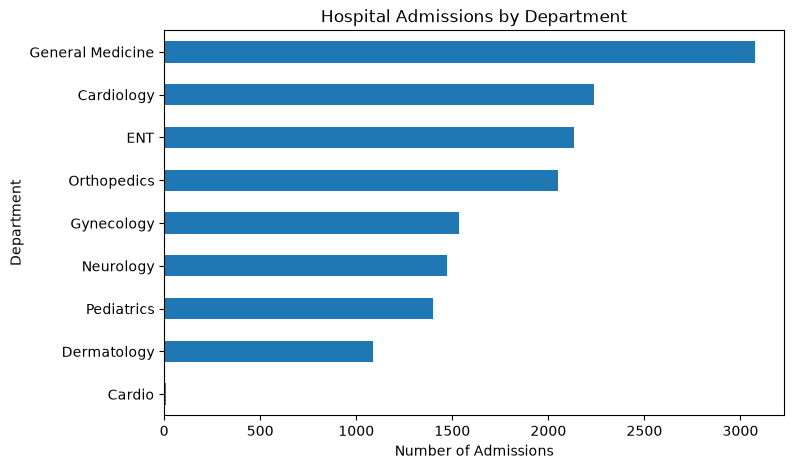

In [162]:
# Visualize admissions by department
import matplotlib.pyplot as plt

department_admissions.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Hospital Admissions by Department")
plt.xlabel("Number of Admissions")
plt.ylabel("Department")
plt.show()

In [ ]:
# Inspect the small "Cardio" category.

df_clean[df_clean["Department"] == "Cardio"][
    ["Admission_ID", "Patient_ID", "Department", "Primary_Condition"]
]

,Admission_ID,Patient_ID,Department,Primary_Condition
419,A100102,P102475,Cardio,Cardiac
1403,A105839,P104973,Cardio,Cardiac
2097,A109337,P101194,Cardio,Cardiac
2835,A111728,P104202,Cardio,Cardiac
5593,A113371,P103627,Cardio,Respiratory
5962,A108957,P104842,Cardio,General
6055,A109860,P100683,Cardio,General
8392,A108855,P100241,Cardio,General
9615,A101718,P102751,Cardio,Respiratory
13217,A102668,P100065,Cardio,Cardiac


In [164]:
# Summarize how many admissions each patient has had.
# This helps us understand repeat hospital utilization.

admissions_per_patient = (
    df_clean.groupby("Patient_ID")
    .size()
)

print("Average admissions per patient:",
      admissions_per_patient.mean())

print("Median admissions per patient:",
      admissions_per_patient.median())

print("\nPatients with exactly 1 admission:",
      (admissions_per_patient == 1).sum())

print("Patients with 2+ admissions:",
      (admissions_per_patient >= 2).sum())

print("Maximum admissions for one patient:",
      admissions_per_patient.max())

Average admissions per patient: 3.1572300568301412
Median admissions per patient: 3.0

Patients with exactly 1 admission: 756
Patients with 2+ admissions: 3995
Maximum admissions for one patient: 10


In [ ]:
# Standardize the department label "Cardio" to "Cardiology".


df_clean["Department"] = df_clean["Department"].replace(
    "Cardio",
    "Cardiology"
)


# Confirm that the duplicate department label no longer exists.

df_clean["Department"].value_counts()

Department
General Medicine    3074
Cardiology          2249
ENT                 2134
Orthopedics         2048
Gynecology          1533
Neurology           1475
Pediatrics          1400
Dermatology         1087
Name: count, dtype: Int64

In [166]:
# Calculate how many times each patient was admitted.
# transform("size") keeps the result aligned with the original rows.

df_clean["Admission_Count"] = (
    df_clean.groupby("Patient_ID")["Admission_ID"]
    .transform("size")
)

# Classify patients into single-admission and repeat-admission groups.

df_clean["Patient_Type"] = df_clean["Admission_Count"].apply(
    lambda x: "Repeat" if x > 1 else "Single"
)

In [167]:
# Compare the number of admissions by patient type.

df_clean["Patient_Type"].value_counts()

Patient_Type
Repeat    14244
Single      756
Name: count, dtype: int64

In [168]:
# Compare the most common conditions between single and repeat patients.

condition_by_patient_type = pd.crosstab(
    df_clean["Primary_Condition"],
    df_clean["Patient_Type"]
)

condition_by_patient_type

Patient_Type,Repeat,Single
Primary_Condition,,
Cardiac,1192,65
ENT,489,31
Fracture/Injury,670,31
Gastrointestinal,1106,63
General,4232,206
Infection,2321,135
Maternity,468,30
Neurological,1135,50
Respiratory,2241,125


In [169]:
# Compare hospital utilization between repeat and single-admission patients.
# This helps us understand whether repeat patients generate
# different lengths of stay or billing compared with single patients.

df_clean.groupby("Patient_Type")[
    [
        "Length_of_Stay_Days",
        "Total_Bill",
        "Waiting_Time_Min"
    ]
].agg(["count", "mean", "median"])

Length_of_Stay_Days                  Total_Bill                \
                           count      mean median      count          mean   
Patient_Type                                                                 
Repeat                     14244  5.373701    5.0      14244  49418.664709   
Single                       756  5.455026    5.0        756  49594.262989   

                        Waiting_Time_Min                    
                 median            count       mean median  
Patient_Type                                                
Repeat        43292.140            14244  56.331648   56.0  
Single        43375.785              756  56.726190   56.0

In [ ]:
# Remove temporary EDA columns that were created only to analyze repeat versus single admissions.

df_clean = df_clean.drop(
    columns=["Admission_Count", "Patient_Type"]
)

In [ ]:
# Compare departments against overall average waiting time.
# This helps identify high-demand departments where waiting time may be an operational bottleneck.

department_summary = (
    df_clean.groupby("Department")
    .agg(
        Admissions=("Admission_ID", "count"),
        Avg_Waiting_Time=("Waiting_Time_Min", "mean"),
        Avg_Total_Bill=("Total_Bill", "mean")
    )
    .sort_values("Admissions", ascending=False)
)

department_summary

,Admissions,Avg_Waiting_Time,Avg_Total_Bill
Department,,,
General Medicine,3074,57.266103,40525.118269
Cardiology,2249,69.436194,80386.246496
ENT,2134,44.552484,27175.802746
Orthopedics,2048,65.698730,67940.611118
Gynecology,1533,52.594260,38179.474475
Neurology,1475,62.495593,75298.609390
Pediatrics,1400,50.616429,32487.837429
Dermatology,1087,36.594296,21928.933542


In [172]:
# Calculate overall benchmarks for comparison with each department.

overall_avg_admissions = df_clean["Admission_ID"].count() / df_clean["Department"].nunique()
overall_avg_waiting = df_clean["Waiting_Time_Min"].mean()
overall_avg_bill = df_clean["Total_Bill"].mean()

print("Average admissions per department:", overall_avg_admissions)
print("Overall average waiting time:", overall_avg_waiting)
print("Overall average bill:", overall_avg_bill)

Average admissions per department: 1875.0
Overall average waiting time: 56.351533333333336
Overall average bill: 49427.51486266667


In [ ]:
# Identify high-demand departments where waiting time is also above the hospital-wide average.

high_demand_bottlenecks = department_summary[
    (department_summary["Admissions"] > overall_avg_admissions) &
    (department_summary["Avg_Waiting_Time"] > overall_avg_waiting)
]

high_demand_bottlenecks

,Admissions,Avg_Waiting_Time,Avg_Total_Bill
Department,,,
General Medicine,3074,57.266103,40525.118269
Cardiology,2249,69.436194,80386.246496
Orthopedics,2048,65.698730,67940.611118


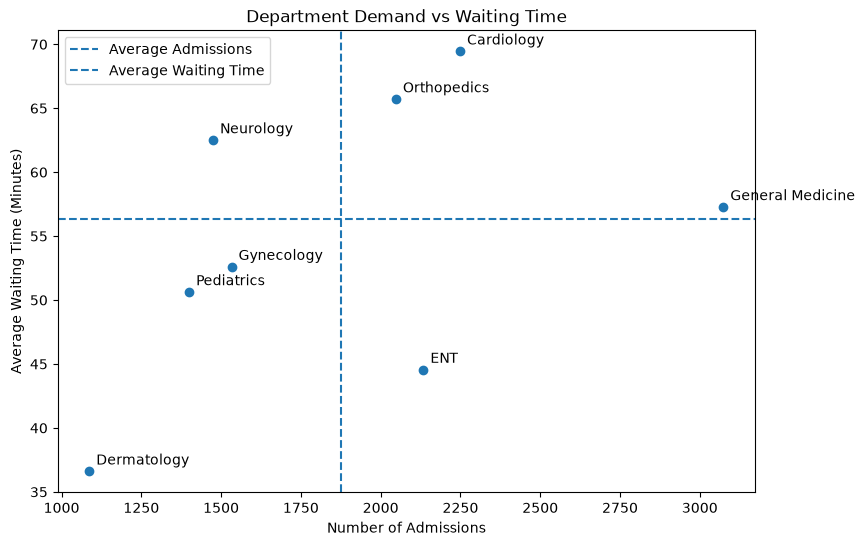

In [ ]:
import matplotlib.pyplot as plt

# Plot admissions against average waiting time.
# This helps identify departments with both high demand and potentially high operational pressure.

plt.figure(figsize=(9, 6))

plt.scatter(
    department_summary["Admissions"],
    department_summary["Avg_Waiting_Time"]
)

# Add department names to each point
for department, row in department_summary.iterrows():
    plt.annotate(
        department,
        (row["Admissions"], row["Avg_Waiting_Time"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Add overall benchmarks
plt.axvline(
    overall_avg_admissions,
    linestyle="--",
    label="Average Admissions"
)

plt.axhline(
    overall_avg_waiting,
    linestyle="--",
    label="Average Waiting Time"
)

plt.title("Department Demand vs Waiting Time")
plt.xlabel("Number of Admissions")
plt.ylabel("Average Waiting Time (Minutes)")
plt.legend()
plt.show()

In [175]:
# Calculate department-level revenue contribution
department_revenue = (
    df_clean.groupby("Department")
    .agg(
        Admissions=("Admission_ID", "count"),
        Total_Revenue=("Total_Bill", "sum"),
        Avg_Bill=("Total_Bill", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
)

department_revenue

,Admissions,Total_Revenue,Avg_Bill
Department,,,
Cardiology,2249,1.807887e+08,80386.246496
Orthopedics,2048,1.391424e+08,67940.611118
General Medicine,3074,1.245742e+08,40525.118269
Neurology,1475,1.110654e+08,75298.609390
Gynecology,1533,5.852913e+07,38179.474475
ENT,2134,5.799316e+07,27175.802746
Pediatrics,1400,4.548297e+07,32487.837429
Dermatology,1087,2.383675e+07,21928.933542


In [176]:
monthly_summary = (
    df_clean
    .set_index("Admission_Date")
    .resample("ME")
    .agg(
        Admissions=("Admission_ID", "count"),
        Total_Revenue=("Total_Bill", "sum"),
        Avg_Bill=("Total_Bill", "mean")
    )
)

monthly_summary

,Admissions,Total_Revenue,Avg_Bill
Admission_Date,,,
2024-01-31,609,29287387.67,48090.948555
2024-02-29,585,27582443.82,47149.476615
2024-03-31,664,32572106.40,49054.377108
2024-04-30,645,33425542.02,51822.545767
2024-05-31,634,32442907.64,51171.778612
2024-06-30,556,27481420.46,49427.015216
2024-07-31,641,31918178.20,49794.349766
2024-08-31,658,32493944.64,49382.894590
2024-09-30,644,31620041.02,49099.442578


In [177]:
monthly_summary.describe()

,Admissions,Total_Revenue,Avg_Bill
count,24.000000,2.400000e+01,24.000000
mean,625.000000,3.089220e+07,49414.007725
std,26.241355,1.656158e+06,1161.963782
min,556.000000,2.748142e+07,47149.476615
25%,614.250000,2.981431e+07,48749.776744
50%,631.500000,3.114851e+07,49295.766082
75%,643.250000,3.234739e+07,50125.764556
max,664.000000,3.342554e+07,51822.545767


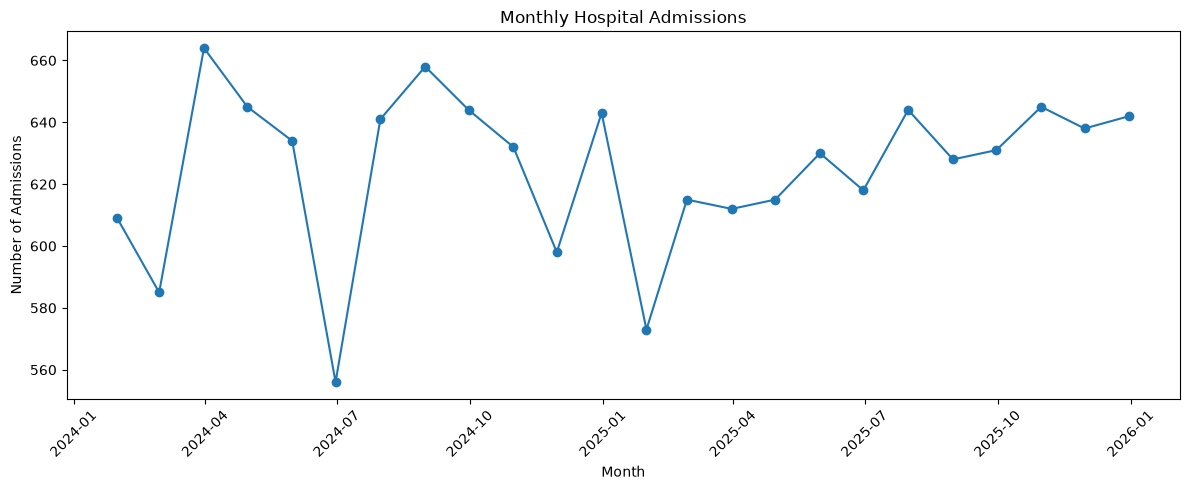

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_summary.index,
    monthly_summary["Admissions"],
    marker="o"
)

plt.title("Monthly Hospital Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [179]:
condition_summary = (
    df_clean
    .groupby("Primary_Condition")
    .agg(
        Admissions=("Admission_ID", "count"),
        Total_Revenue=("Total_Bill", "sum"),
        Avg_Bill=("Total_Bill", "mean"),
        Avg_LOS=("Length_of_Stay_Days", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
)

condition_summary

,Admissions,Total_Revenue,Avg_Bill,Avg_LOS
Primary_Condition,,,,
General,4438,2.011564e+08,45325.913909,4.791798
Respiratory,2366,1.192424e+08,50398.316551,5.704987
Cardiac,1257,1.095306e+08,87136.554304,7.860780
Neurological,1185,8.867765e+07,74833.462743,7.167932
Infection,2456,8.607358e+07,35046.245851,4.767508
Fracture/Injury,701,5.100883e+07,72765.800114,7.118402
Gastrointestinal,1169,4.427049e+07,37870.397391,4.940120
Maternity,498,1.969299e+07,39544.156044,4.439759
ENT,520,1.326217e+07,25504.165635,3.328846


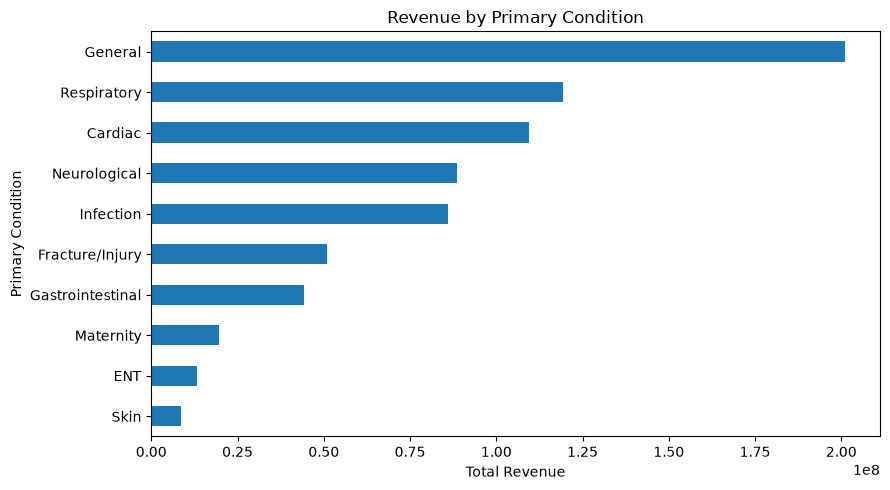

In [180]:
import matplotlib.pyplot as plt

condition_summary["Total_Revenue"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Revenue by Primary Condition")
plt.xlabel("Total Revenue")
plt.ylabel("Primary Condition")
plt.tight_layout()
plt.show()

In [181]:
payer_summary = (
    df_clean
    .groupby("Insurance_Type")
    .agg(
        Admissions=("Admission_ID", "count"),
        Total_Revenue=("Total_Bill", "sum"),
        Avg_Bill=("Total_Bill", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
)

payer_summary

,Admissions,Total_Revenue,Avg_Bill
Insurance_Type,,,
Private,6287,3.114000e+08,49530.779200
Government,3815,1.861689e+08,48799.199405
Corporate,2637,1.315735e+08,49895.157562
Self-Pay,2196,1.092314e+08,49741.081821
Unknown,65,3.038822e+06,46751.110923


In [182]:
admission_type_summary = (
    df_clean
    .groupby("Admission_Type")
    .agg(
        Admissions=("Admission_ID", "count"),
        Avg_Waiting_Time=("Waiting_Time_Min", "mean"),
        Avg_Bill=("Total_Bill", "mean")
    )
    .sort_values("Admissions", ascending=False)
)

admission_type_summary

,Admissions,Avg_Waiting_Time,Avg_Bill
Admission_Type,,,
Emergency,4477,76.127317,55772.333286
Scheduled,4472,38.944991,46222.525208
Walk-in,3333,53.495950,45633.006502
Referral,2718,55.918690,48902.885732


In [183]:
doctor_summary = (
    df_clean
    .groupby("Doctor")
    .agg(
        Admissions=("Admission_ID", "count"),
        Total_Revenue=("Total_Bill", "sum"),
        Avg_Bill=("Total_Bill", "mean")
    )
    .sort_values("Admissions", ascending=False)
)

doctor_summary.head(10)

,Admissions,Total_Revenue,Avg_Bill
Doctor,,,
Dr. Rao,1554,62835805.66,40434.881377
Dr. Sharma,1510,61351886.55,40630.388444
Dr. Mehta,1152,92598195.78,80380.378281
Dr. Patil,1101,29761618.86,27031.443106
Dr. Khan,1082,87048541.49,80451.517089
Dr. Deshmukh,1022,69707789.21,68207.230147
Dr. Gupta,1019,27867503.91,27347.893925
Dr. Patel,1015,68677750.16,67662.808039
Dr. Kulkarni,804,30530707.13,37973.516331


In [184]:
admission_type_summary = (
    df_clean
    .groupby("Admission_Type")
    .agg(
        Admissions=("Admission_ID", "count"),
        Avg_Waiting_Time=("Waiting_Time_Min", "mean"),
        Avg_Bill=("Total_Bill", "mean"),
        Total_Revenue=("Total_Bill", "sum")
    )
    .sort_values("Admissions", ascending=False)
)

admission_type_summary

,Admissions,Avg_Waiting_Time,Avg_Bill,Total_Revenue
Admission_Type,,,,
Emergency,4477,76.127317,55772.333286,2.496927e+08
Scheduled,4472,38.944991,46222.525208,2.067071e+08
Walk-in,3333,53.495950,45633.006502,1.520948e+08
Referral,2718,55.918690,48902.885732,1.329180e+08


In [185]:
# Save the final cleaned dataset as a CSV file.
# index=False prevents Pandas from adding the DataFrame index
# as an unnecessary column in the Power BI dataset.

df_clean.to_csv(
    "hospital_admissions_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [186]:
# Verify the exported file can be read back correctly.

df_check = pd.read_csv("hospital_admissions_clean.csv")

print("Shape:", df_check.shape)
print("Columns:", df_check.columns.tolist())

Shape: (15000, 20)
Columns: ['Admission_ID', 'Patient_ID', 'Patient_Name', 'Admission_Date', 'Discharge_Date', 'Department', 'Primary_Condition', 'Admission_Type', 'Patient_Age', 'Gender', 'City', 'Doctor', 'Insurance_Type', 'Payment_Method', 'Waiting_Time_Min', 'Length_of_Stay_Days', 'Room_Charges', 'Treatment_Charges', 'Medication_Charges', 'Total_Bill']


In [187]:
# Show the folder where the CSV was saved.

import os

print(os.path.abspath("hospital_admissions_clean.csv"))

c:\Users\DELL\Music\Hospital_Data_Project\hospital_admissions_clean.csv
